# Mean-Variance Portfolio Optimization with cuOpt

<div style="background-color: #e3f2fd; border-left: 6px solid #1976d2; padding: 15px; margin: 15px 0;">
<h4 style="margin-top: 0;">📘 Optional Notebook</h4>
We now support solving <strong>Quadratic Programs (QP)</strong>, enabling standard <strong>Markowitz Mean-Variance</strong> portfolio optimization directly on the GPU.

This notebook shows how the same framework extends to QP problems with a quadratic objective with variance as the risk measure <code>w'Σw</code>.
</div>


## Table of Contents

1. [Setup](#setup) — GPU check & imports
2. [Mathematical Formulation](#introduction) — The Markowitz QP
3. [Solve with cuOpt](#solve) — Data, parameters & GPU optimization
4. [Results](#analyze) — Portfolio visualization & statistics
5. [CPU Solver Comparison](#cpu-comparison) — Clarabel vs cuOpt


---

<a id='setup'></a>
## 1. Setup


In [1]:
!nvidia-smi

Mon Apr 13 02:48:51 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 590.48.01              Driver Version: 590.48.01      CUDA Version: 13.1     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA H200                    On  |   00000000:9D:00.0 Off |                    0 |
| N/A   33C    P0             76W /  700W |       0MiB / 143771MiB |      0%      Default |
|                                         |                        |             Disabled |
+-----------------------------------------+-----

In [2]:
import os

import numpy as np
import cvxpy as cp

from cufolio import mean_variance_optimizer, utils
from cufolio.mean_variance_parameters import MeanVarianceParameters
from cufolio.settings import ApiSettings, ReturnsComputeSettings

---

<a id='introduction'></a>
## 2. Mathematical Formulation

<div style="background-color: #f3e5f5; border-left: 6px solid #9c27b0; padding: 15px; margin: 15px 0;">
<h4 style="margin-top: 0;">💡 Mean-Variance (Markowitz) Optimization</h4>
Mean-Variance optimization, introduced by Harry Markowitz in 1952, is the foundation of Modern Portfolio Theory. The objective trades off expected return against portfolio variance:

\begin{align*}
\text{maximize } \quad &\mu^\top w - \lambda_{\text{risk}} \cdot w^\top \Sigma w\\
\text{subject to} \quad 
& \sum_i w_i + c = 1 \quad \text{(self-financing)}\\
& w_i^{\text{min}} \leq w_i \leq w_i^{\text{max}}, \forall i \quad \text{(concentration)}\\
& c^{\text{min}} \leq c \leq c^{\text{max}} \quad \text{(cash)}\\
& L = \|w\|_1 \leq L^{\text{limit}} \quad \text{(leverage)}\\
& T = \|w - w_{\text{prev}}\|_1 \leq T^{\text{limit}} \quad \text{(turnover)}
\end{align*}

This is a **Quadratic Program (QP)** due to the $w^\top \Sigma w$ term. cuOpt 26.02 introduces QP support via a GPU-accelerated barrier solver.
</div>


---

<a id='solve'></a>
## 3. Solve with cuOpt

<div style="background-color: #e8f5e9; border-left: 6px solid #388e3c; padding: 15px; margin: 15px 0;">
<h4 style="margin-top: 0;">🚀 End-to-End: Data → Parameters → GPU Solve</h4>
We load S&P 500 price data, compute log-returns, define portfolio constraints, and solve the QP on the GPU using cuOpt.
</div>

<div style="background-color: #fff8e1; border-left: 6px solid #f9a825; padding: 15px; margin: 15px 0;">
<h4 style="margin-top: 0;">⚠️ Disclaimer</h4>
Each user is responsible for checking the content of datasets and the applicable licenses and determining if suitable for the intended use.
</div>


In [3]:
dataset_name = "sp500"
data_path = f"../data/stock_data/{dataset_name}.csv"

if not os.path.exists(data_path):
    utils.download_data(data_path)

returns_dict = utils.calculate_returns(
    data_path,
    {"name": "recent", "range": ("2022-01-01", "2024-01-01")},
    ReturnsComputeSettings(return_type="LOG", freq=1),
)

print(f"Assets: {len(returns_dict['tickers'])}  |  "
      f"Observations: {len(returns_dict['returns'])}  |  "
      f"Covariance: {returns_dict['covariance'].shape}")


Assets: 392  |  Observations: 500  |  Covariance: (392, 392)


In [4]:
mean_variance_params = MeanVarianceParameters(
    w_min={"NVDA": 0.1, "others": -0.3},
    w_max={"NVDA": 0.6, "others": 0.4},
    c_min=0.0,
    c_max=0.2,
    L_tar=1.6,
    risk_aversion=1.0,
)


### Solve with CVXPY API

In [ ]:
mean_variance_problem = mean_variance_optimizer.MeanVariance(
    returns_dict=returns_dict,
    mean_variance_params=mean_variance_params,
    api_settings=ApiSettings(api="cvxpy"),
)

gpu_results, gpu_portfolio = mean_variance_problem.solve_optimization_problem(
    solver_settings={"solver": cp.CUOPT, "time_limit": 60, "verbose": True}
)

(CVXPY) Apr 13 02:49:51 AM: Your problem has 393 variables, 2 constraints, and 2 parameters.
(CVXPY) Apr 13 02:49:51 AM: It is compliant with the following grammars: DCP, DQCP
(CVXPY) Apr 13 02:49:51 AM: DCP verification time: 0.0001 seconds.
(CVXPY) Apr 13 02:49:51 AM: Expression tree has 8 nodes.
(CVXPY) Apr 13 02:49:51 AM: CVXPY will first compile your problem; then, it will invoke a numerical solver to obtain a solution.
(CVXPY) Apr 13 02:49:51 AM: Your problem is compiled with the CPP canonicalization backend.
(CVXPY) Apr 13 02:49:51 AM: Compiling problem (target solver=CUOPT).
(CVXPY) Apr 13 02:49:51 AM: Reduction chain: Dcp2Cone -> CvxAttr2Constr -> EliminateZeroSized -> ConeMatrixStuffing -> CUOPT
(CVXPY) Apr 13 02:49:51 AM: Applying reduction Dcp2Cone
(CVXPY) Apr 13 02:49:51 AM: Applying reduction CvxAttr2Constr
(CVXPY) Apr 13 02:49:51 AM: Applying reduction EliminateZeroSized
(CVXPY) Apr 13 02:49:51 AM: Applying reduction ConeMatrixStuffing
(CVXPY) Apr 13 02:49:51 AM: Applyin

                                     CVXPY                                     
                             v1.9.0.dev0+0.f006ffa                             
-------------------------------------------------------------------------------
                                  Compilation                                  
-------------------------------------------------------------------------------
-------------------------------------------------------------------------------
                                Numerical solver                               
-------------------------------------------------------------------------------


(CVXPY) Apr 13 02:49:51 AM: Problem status: optimal
(CVXPY) Apr 13 02:49:51 AM: Optimal value: -2.890e-03
(CVXPY) Apr 13 02:49:51 AM: Compilation took 2.819e-02 seconds
(CVXPY) Apr 13 02:49:51 AM: Solver (including time spent in interface) took 2.591e-01 seconds


Setting parameter log_to_console to true
Setting parameter time_limit to 6.000000e+01
cuOpt version: 26.2.0, git hash: f73da24d, host arch: x86_64, device archs: 75-real,80-real,86-real,90a-real,100f-real,120a-real,120
CPU: Intel(R) Xeon(R) Platinum 8480C, threads (physical/logical): 112/224, RAM: 1965.85 GiB
CUDA 13.1, device: NVIDIA H200 (ID 0), VRAM: 139.80 GiB
CUDA device UUID: ffffffdbfffffffb4372-ffffffce15-ffff

Problem has a quadratic objective. Using Barrier.
Solving a problem with 786 constraints, 785 variables (0 integers), and 2353 nonzeros
Problem scaling:
Objective coefficents range:          [1e-06, 3e-03]
Constraint matrix coefficients range: [1e+00, 1e+00]
Constraint rhs / bounds range:        [0e+00, 2e+00]
Variable bounds range:                [1e-01, 6e-01]

Third-party presolve is disabled, skipping
Objective offset 0.000000 scaling_factor 1.000000
Transforming 392 nonzero lower bound
Presolved problem: 786 constraints 1962 variables 641245304 nonzeros
Skipping col

### Solve using cuOpt Python API

In [ ]:
mean_variance_problem = mean_variance_optimizer.MeanVariance(
    returns_dict=returns_dict,
    mean_variance_params=mean_variance_params,
    api_settings=ApiSettings(api="cuopt_python"),
)

gpu_results, gpu_portfolio = mean_variance_problem.solve_optimization_problem(
    solver_settings={"time_limit": 60, "log_to_console": True}
)

cuOpt MEAN-VARIANCE (QP) PROBLEM SETUP COMPLETED
Variables: 392 weights + 1 cash + 784 leverage aux
Covariance matrix: 392x392
Linear terms: 392
Problem Type: QP (Quadratic Programming)
Setting parameter time_limit to 6.000000e+01
Setting parameter log_to_console to true
cuOpt version: 26.2.0, git hash: f73da24d, host arch: x86_64, device archs: 75-real,80-real,86-real,90a-real,100f-real,120a-real,120
CPU: Intel(R) Xeon(R) Platinum 8480C, threads (physical/logical): 112/224, RAM: 1965.74 GiB
CUDA 13.1, device: NVIDIA H200 (ID 0), VRAM: 139.80 GiB
CUDA device UUID: ffffffdbfffffffb4372-ffffffce15-ffff

Problem has a quadratic objective. Using Barrier.
Solving a problem with 394 constraints, 1177 variables (0 integers), and 2353 nonzeros
Problem scaling:
Objective coefficents range:          [1e-06, 3e-03]
Constraint matrix coefficients range: [1e+00, 1e+00]
Constraint rhs / bounds range:        [0e+00, 2e+00]
Variable bounds range:                [1e-01, 6e-01]

Third-party presolve is 

regime          recent
solver           cuOpt
solve time    0.158607
return        0.002914
variance      0.000235
obj          -0.002892
dtype: object

---

<a id='analyze'></a>
## 4. Results


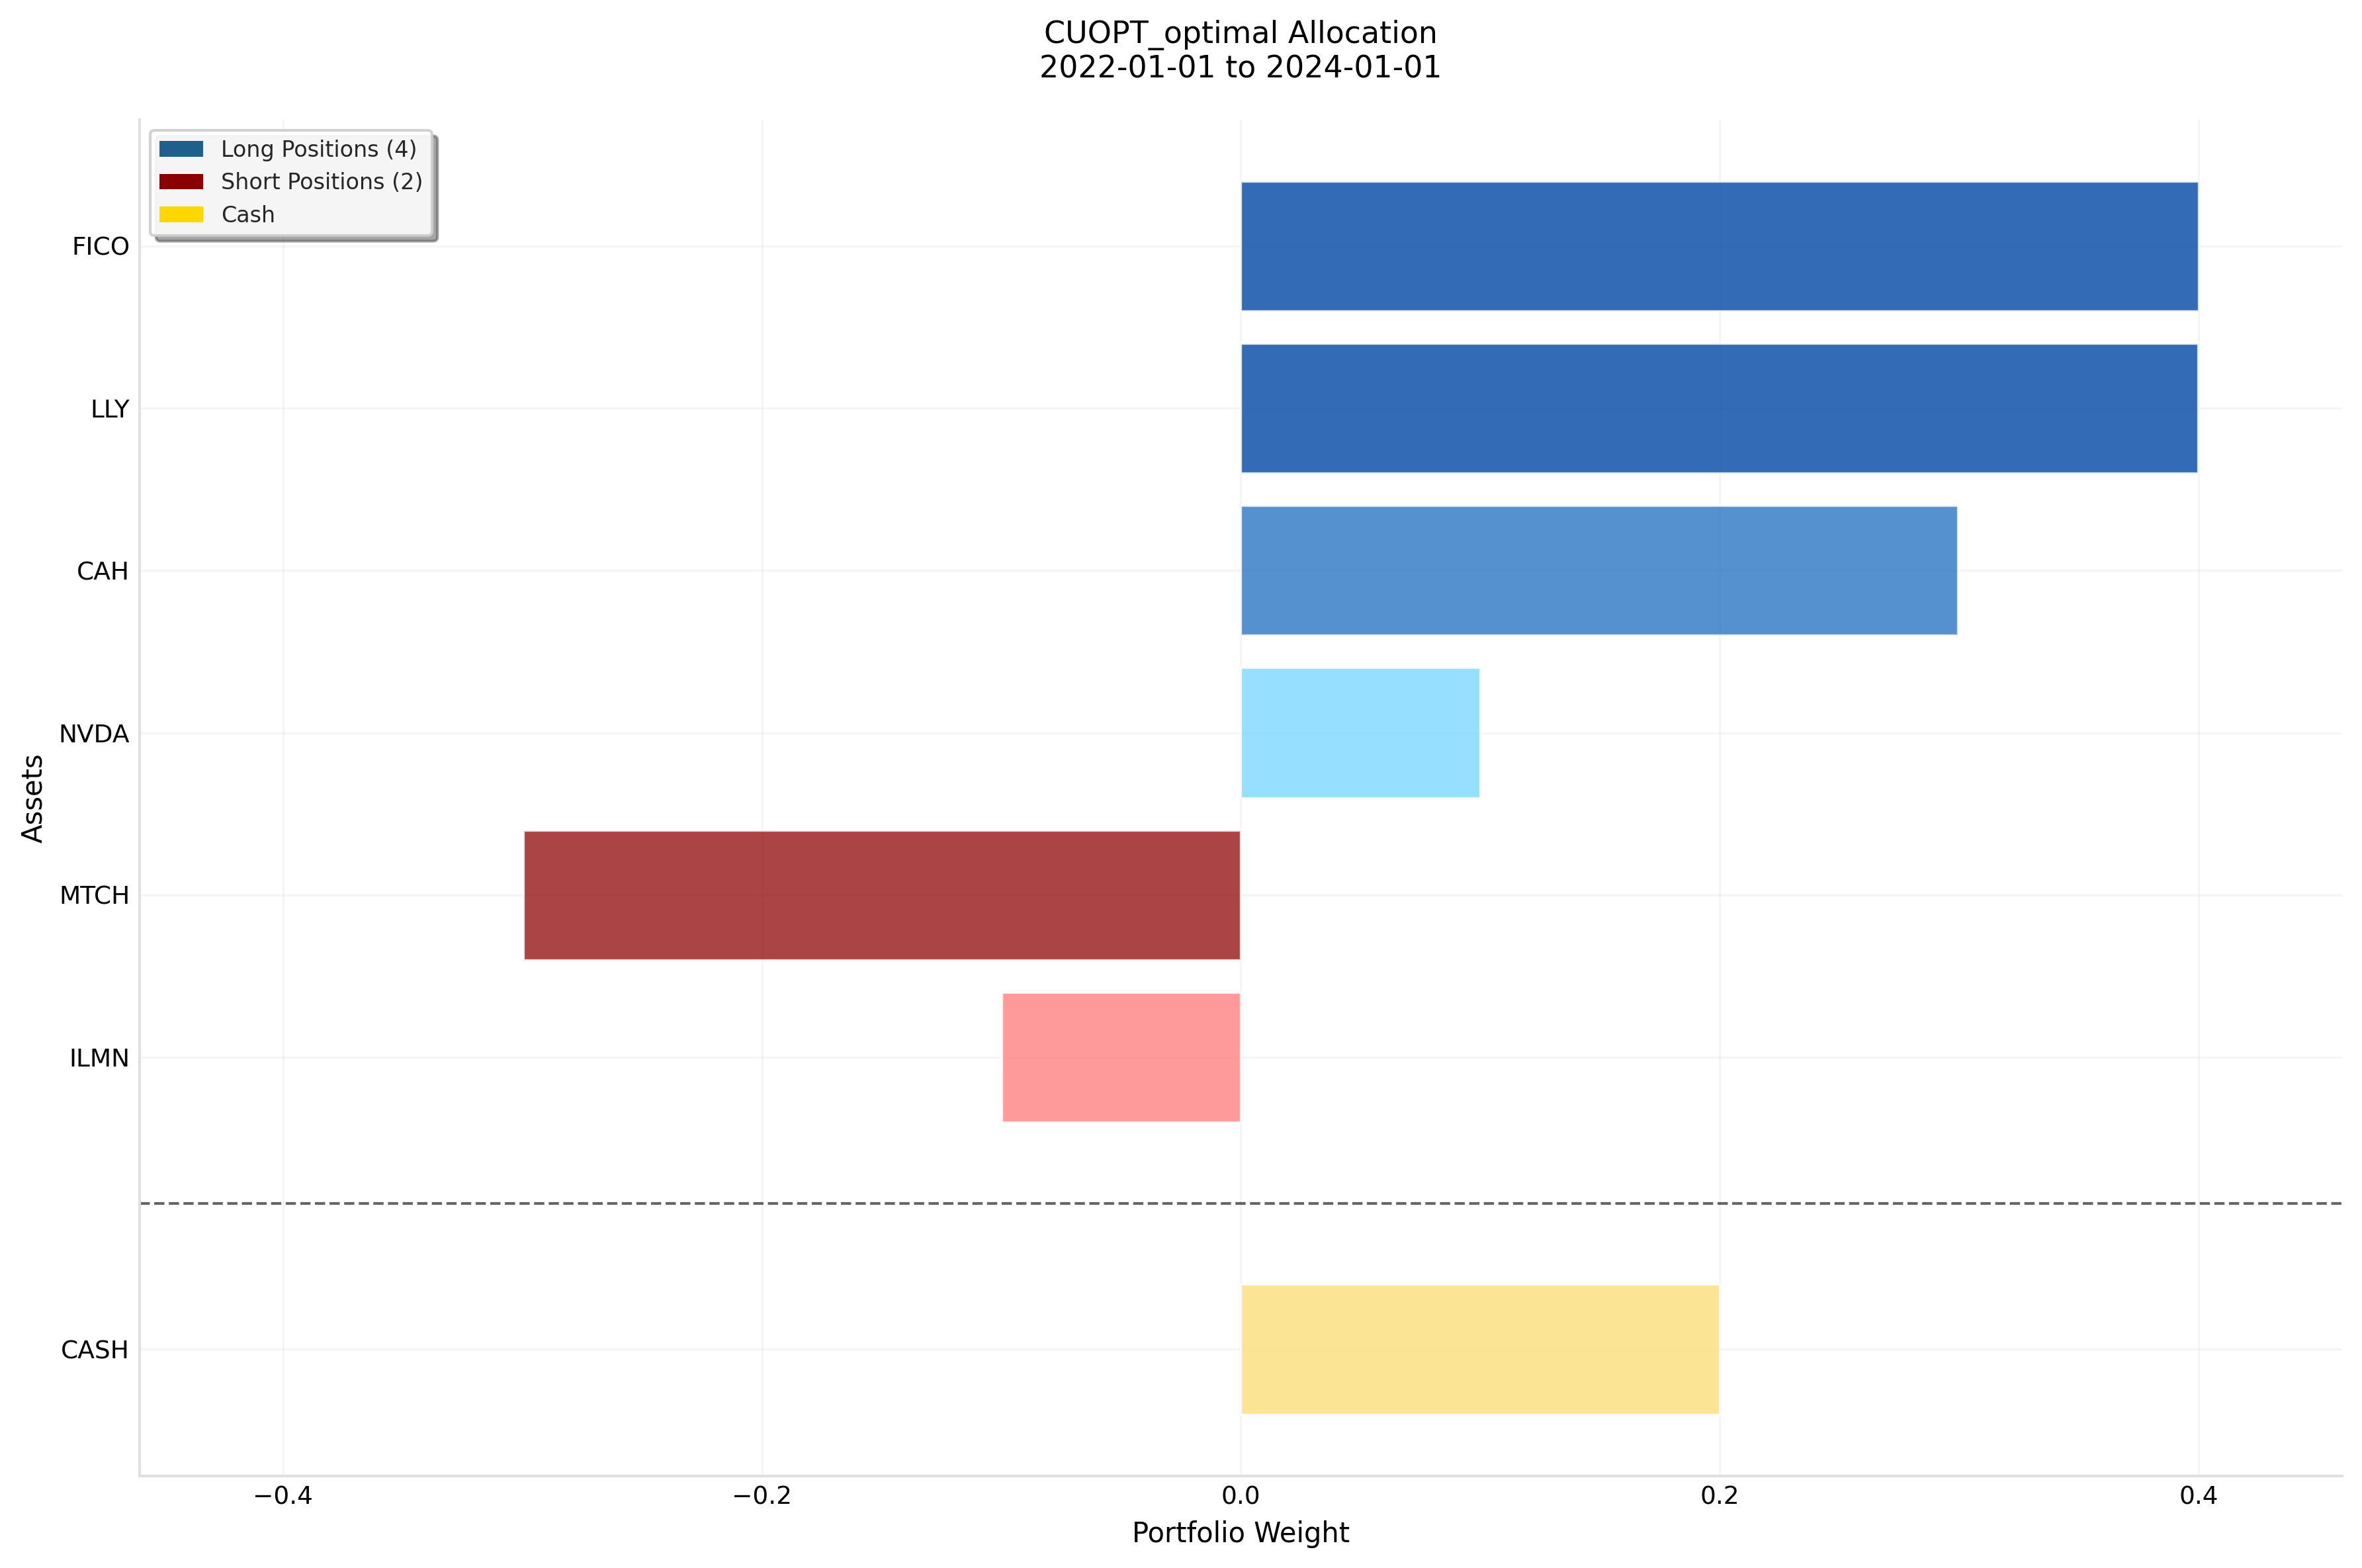

In [10]:
ax = gpu_portfolio.plot_portfolio(show_plot=True, min_percentage=1)


In [8]:
weights = gpu_portfolio.weights

expected_return = np.dot(returns_dict["mean"], weights)
portfolio_variance = weights @ returns_dict["covariance"] @ weights
portfolio_std = np.sqrt(portfolio_variance)
sharpe_ratio = expected_return / portfolio_std if portfolio_std > 0 else 0

print("Portfolio Statistics:")
print(f"  Expected Return: {expected_return:.4%}")
print(f"  Volatility (Std): {portfolio_std:.4%}")
print(f"  Variance: {portfolio_variance:.6f}")
print(f"  Sharpe Ratio: {sharpe_ratio:.4f}")
print(f"  Cash Allocation: {gpu_portfolio.cash:.2%}")
print(f"  Leverage: {np.sum(np.abs(weights)):.4f}")
print(f"  Number of positions: {np.sum(np.abs(weights) > 0.001)}")


Portfolio Statistics:
  Expected Return: 0.2912%
  Volatility (Std): 1.5320%
  Variance: 0.000235
  Sharpe Ratio: 0.1901
  Cash Allocation: 20.00%
  Leverage: 1.5994
  Number of positions: 6


---

<a id='cpu-comparison'></a>
## 5. CPU Solver Comparison

<div style="background-color: #fff3e0; border-left: 6px solid #f57c00; padding: 15px; margin: 15px 0;">
<h4 style="margin-top: 0;">🔄 GPU vs CPU</h4>
Solve the same Mean-Variance problem using <strong>Clarabel</strong> (a CPU-based interior-point solver) and compare the results against the GPU solution above. For small portfolios the GPU advantage in solve time alone may be modest, but running the entire pipeline on GPU — data preprocessing, returns forecasting, scenario generation, and optimization — eliminates costly CPU↔GPU data transfers and delivers end-to-end speedups that grow with problem size.
</div>

In [16]:
cpu_problem = mean_variance_optimizer.MeanVariance(
    returns_dict=returns_dict,
    mean_variance_params=mean_variance_params,
    api_settings=ApiSettings(api="cvxpy"),
)

cpu_results, cpu_portfolio = cpu_problem.solve_optimization_problem(
    solver_settings={"solver": cp.CLARABEL}
)


MEAN-VARIANCE OPTIMIZATION RESULTS
PROBLEM CONFIGURATION
------------------------------
Solver:              CLARABEL
Regime:              recent
Time Period:         2022-01-01 to 2024-01-01
Assets:              392

PERFORMANCE METRICS
------------------------------
Expected Return:     0.002914 (0.2914%)
Variance:            0.000235
Std Deviation:       0.015327
Objective Value:     -0.002892

SOLVING PERFORMANCE
------------------------------
Setup Time:          0.0006 seconds
CVXPY API Overhead:  0.0071 seconds
Solve Time:          0.0974 seconds

OPTIMAL PORTFOLIO ALLOCATION
------------------------------

PORTFOLIO: CLARABEL_OPTIMAL
----------------------------------------
Period: 2022-01-01 to 2024-01-01

LONG POSITIONS (4 assets)
-------------------------
FICO        0.400 ( 40.00%)
LLY         0.400 ( 40.00%)
CAH         0.300 ( 30.00%)
NVDA        0.100 ( 10.00%)
Total Long    1.200 (120.00%)

SHORT POSITIONS (2 assets)
--------------------------
MTCH       -0.300 (-30.00

In [15]:
utils.compare_results(gpu_results.to_dict(), cpu_results.to_dict())


SOLVER COMPARISON
Solver          solve time   obj          return       variance    
----------------------------------------------------------------------
cuOpt           0.158607     -0.002892    0.002914     0.000235    
CLARABEL        0.097250     -0.002892    0.002914     0.000235    

Objective Differences:
  cuOpt vs CLARABEL: 0.00000010



---

## Summary

<div style="background-color: #e8f5e9; border-left: 6px solid #388e3c; padding: 15px; margin: 15px 0;">
<h4 style="margin-top: 0;">✅ Key Takeaway</h4>
<strong>cuOpt >= 26.02</strong> adds QP support, enabling GPU-accelerated Markowitz Mean-Variance optimization alongside the existing LP-based CVaR solver. The same cuFOLIO framework handles both problem types — simply choose the appropriate optimizer class.

### Mean-Variance vs CVaR

| Aspect | Mean-Variance | CVaR |
|--------|---------------|------|
| Risk Measure | Variance (symmetric) | Tail risk (asymmetric) |
| Problem Type | QP (Quadratic) | LP (Linear) |
| Data Needed | Mean + Covariance | Scenarios |
| Distribution | Assumes normal | Distribution-free |

</div>
